<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/JeeRankprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [119]:
df=pd.read_csv('/content/jee_marks_percentile_rank_2009_2026.csv')

In [120]:
df.shape

(1620, 5)

In [121]:
df.isnull().sum()

,0
Year,0
Marks,0
Percentile,0
Rank,0
Total_Candidates,0


In [122]:
df.duplicated().sum()

np.int64(0)

#Eda steps in this dataset

In [123]:
df['Year'].describe()

,Year
count,1620.000000
mean,2017.500000
std,5.189729
min,2009.000000
25%,2013.000000
50%,2017.500000
75%,2022.000000
max,2026.000000


In [124]:
#histograms
fig=plt.figure(figsize=(15,15))

<Figure size 1500x1500 with 0 Axes>

<Axes: xlabel='Year', ylabel='Count'>

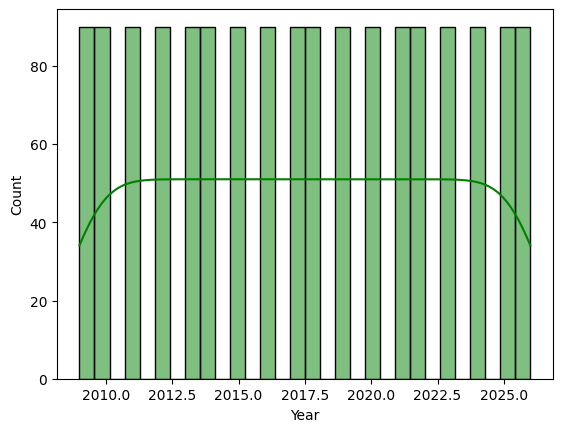

In [125]:
sns.histplot(data=df,x='Year',kde=True,bins=30,color="green")

In [126]:
df['Year'].skew()

np.float64(0.0)

In [127]:
df['Percentile'].describe()

,Percentile
count,1620.000000
mean,68.040127
std,34.111475
min,0.317587
25%,28.979665
50%,84.749529
75%,96.312400
max,100.000000


Text(0.5, 1.0, 'Boxplot of Percentiles')

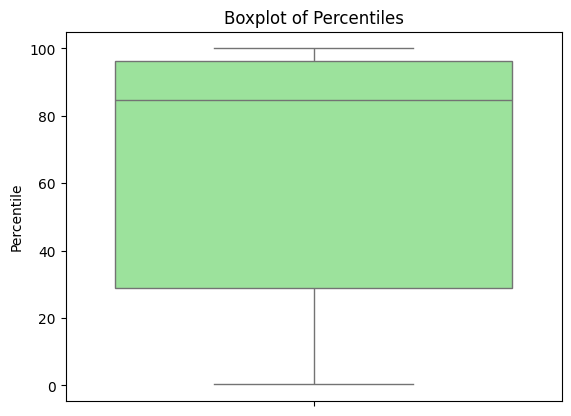

In [128]:

sns.boxplot(y=df['Percentile'], color='lightgreen')
plt.title('Boxplot of Percentiles')

In [129]:
import plotly.express as px



In [130]:
fig2=px.box(df,x='Percentile')
fig2.show()

In [131]:
fig2=px.box(df,x='Marks')
fig2.show()

Text(0.5, 1.0, 'Distribution of Marks')

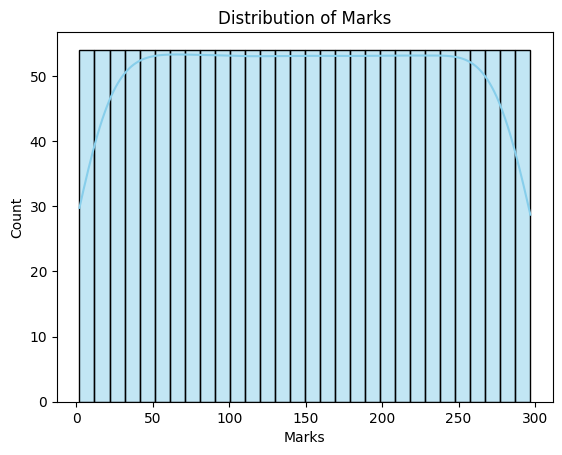

In [132]:
sns.histplot(df['Marks'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Marks')

#“Lack of distinction in KDE indicates high consistency in marks distribution across years.”

In [133]:
import plotly.figure_factory as ff

years = df['Year'].unique()

data = []
labels = []

for year in years:
    data.append(df[df['Year'] == year]['Marks'])
    labels.append(str(year))

fig = ff.create_distplot(
    data,
    labels,
    show_hist=False,   # only KDE curves
    show_rug=False
)

fig.update_layout(
    title="Interactive KDE Plot of Marks by Year",
    xaxis_title="Marks",
    yaxis_title="Density"
)

fig.show()

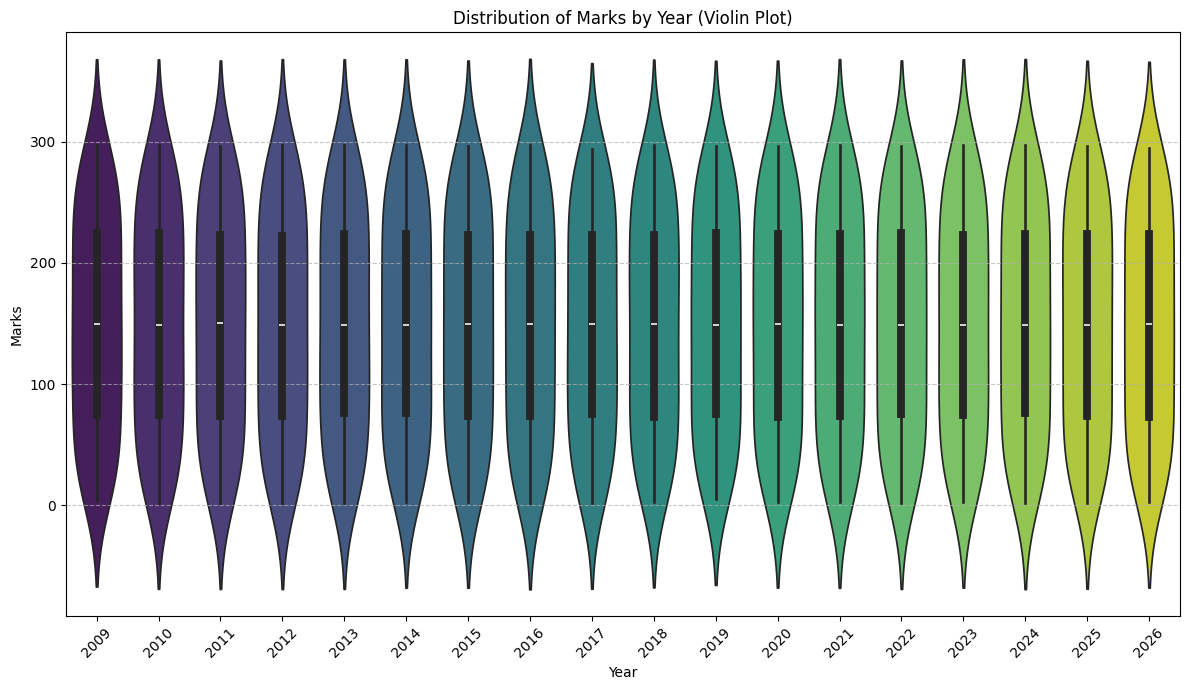

In [134]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='Year', y='Marks', palette='viridis')
plt.title('Distribution of Marks by Year (Violin Plot)')
plt.xlabel('Year')
plt.ylabel('Marks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [135]:
import plotly.express as px

fig = px.violin(
    df,
    x="Year",
    y="Marks",
    box=True,        # shows box inside

    color="Year"     # color by year
)

fig.show()

In [136]:
df['Rank'].describe()

,Rank
count,1.620000e+03
mean,3.684445e+05
std,4.008154e+05
min,1.000000e+00
25%,4.491550e+04
50%,1.646180e+05
75%,6.721380e+05
max,1.379224e+06


<Axes: xlabel='Total_Candidates', ylabel='Density'>

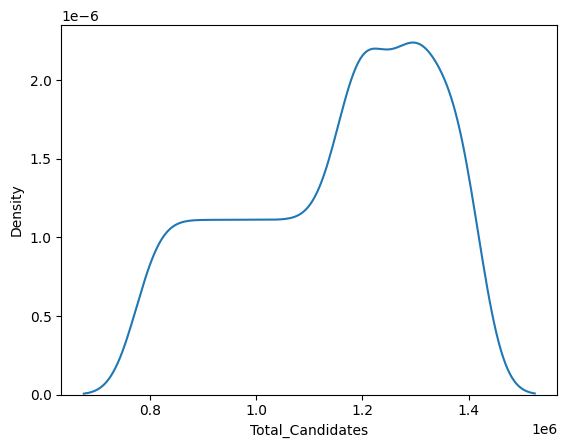

In [137]:
sns.kdeplot(data=df,x='Total_Candidates')

Primary Peak (Mode): The highest density is between 1.2 million and 1.4 million candidates. This suggests that for a large portion of the dataset (likely the most recent years), the candidate count has stabilized in this high range.

Secondary Peak/Shoulder: There is a smaller plateau or "shoulder" around 0.8 million to 1.0 million candidates, representing earlier years in the dataset when the number of aspirants was lower.

Competition Level: The density being heavily concentrated towards the right (higher values) indicates that the model you are building will be trained mostly on "high-competition" scenarios (over 1.2M students).

Consistency: The distinct peaks suggest there were specific periods where the candidate count remained relatively stable before jumping to a new level (likely due to policy changes or the merger of different exam phases).

In [138]:
df['Total_Candidates'].skew()

np.float64(-0.4499044877341955)

#Bivariate Analysis

In [139]:
#rank with Total_Candidates

Based on the scatter plot of Rank vs. Total_Candidates shown in your JeeRankprediction.ipynb notebook, here are three key conclusions:

Upper Bound Expansion: There is a direct positive correlation between the total number of candidates and the maximum rank. As the candidate pool grows from 0.8 million to 1.4 million, the "ceiling" for ranks increases proportionally. This confirms that rank is a relative metric directly capped by the total participant count for that year.

Increased Rank Volatility: The vertical spread of data points becomes significantly taller as you move to the right (towards 1.4M candidates). This indicates that in high-competition years, there is a much wider range of ranks distributed across the same marks/percentile scale, meaning small differences in performance result in much larger numerical shifts in rank.

Discrete Year-on-Year Growth: The data appears in distinct vertical "strips" rather than a continuous cloud. This shows that Total_Candidates acts as a constant for each specific year/exam cycle. The gaps between these strips reflect the historical jumps in JEE registration numbers over the period from 2009 to 2026.

In [140]:
px.scatter(df,x='Total_Candidates',y='Rank')

#As total no of candidates increase the rank increases on the same marks

In [141]:
px.bar(df, x='Total_Candidates',y='Rank',color='Marks')

Based on the stacked bar chart in your JeeRankprediction.ipynb notebook:

Rank Inflation: As total candidates grow (0.8M to 1.4M), the "total rank volume" (bar height) expands, showing higher competition levels.

Performance Hierarchy: Higher marks (yellow/light) consistently occupy the lowest rank positions at the bottom of every bar across all years.

Consistency: The proportional distribution of marks within each bar remains stable, despite the overall increase in student population. and also at different years same marks give out different ranks which are higher

In [142]:
import plotly.express as px

fig = px.line(df,
              x="Percentile",
              y="Rank",
              facet_col="Year",      # This creates the "space" by separating years
              facet_col_wrap=4,      # Sets 4 plots per row
              color="Year",
              title="Rank vs Percentile (Faceted by Year)",
              height=1000,           # Increased height to give more vertical space
              template="plotly_white")

# Reverse Y-axis for every subplot so Rank 1 is at the top
fig.update_yaxes(autorange="reversed")

fig.show()

# at same percentile there is different rank across each year due to increasing no of candidates

In [143]:
fig = px.scatter(df, x='Total_Candidates', y='Rank', title='Rank vs Total Candidates',)
fig.update_xaxes(title_text='Total Candidates')
fig.update_yaxes(title_text='Rank')
fig.show()

In [144]:
fig = px.scatter(df, x='Total_Candidates', y='Rank', title='Rank vs Total Candidates',color='Marks')
fig.update_xaxes(title_text='Total Candidates')
fig.update_yaxes(title_text='Rank')
fig.show()

In [145]:
fig = px.scatter(df, x='Rank', y='Marks', color='Percentile',
                 title='Rank vs Marks (Log Scale)',
                 log_x=True) # This is the magic line
fig.show()

The 10x Jump: Notice that the physical "distance" on the graph from Rank 100 to Rank 1,000 is the same as the distance from Rank 10,000 to Rank 100,000.

The Mark Gap: To move from Rank 1,000 up to Rank 100, you might need an extra 40 marks. But to move from Rank 1,000,000 up to 900,000, you might only need 2 marks.

Conclusion: This shows that as you get closer to the left (the toppers), competition gets 10 times tougher. Every single mark you gain pushes you past a much smaller, more "elite" group of people compared to the crowd at the bottom.

<Axes: >

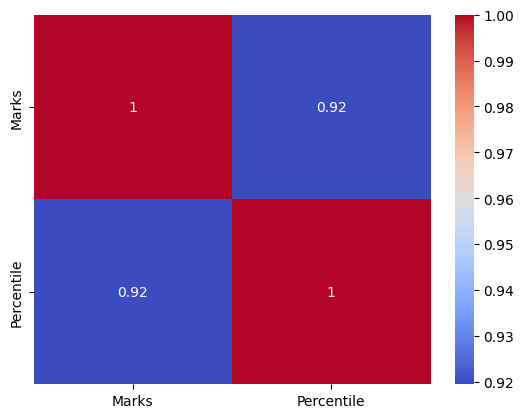

In [146]:
#correlation of two columns
sns.heatmap(df[['Marks','Percentile']].corr(),annot=True,cmap='coolwarm')#close correlation

<Axes: >

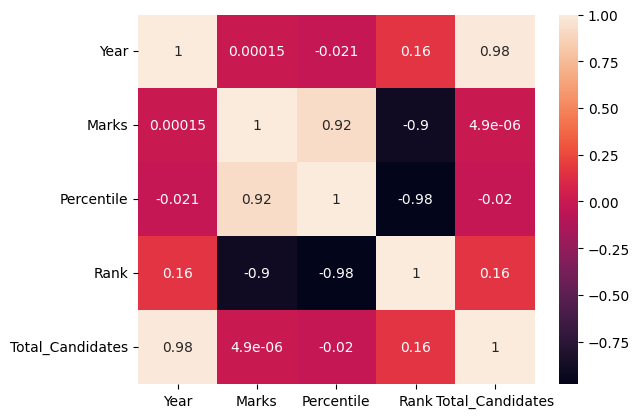

In [147]:
sns.heatmap(df.corr(),annot=True)

In [148]:
def rankRatio(dataframe):
  dataframe['RankRatio']=dataframe['Rank']/dataframe['Total_Candidates']
  return dataframe

In [149]:
df=df.apply(rankRatio, axis=1)


In [150]:
df

,Year,Marks,Percentile,Rank,Total_Candidates,RankRatio
0,2009.0,296.0,100.000000,1.0,800000.0,0.000001
1,2009.0,295.0,100.000000,1.0,800000.0,0.000001
2,2009.0,297.0,100.000000,1.0,800000.0,0.000001
3,2009.0,284.0,99.619975,3040.0,800000.0,0.003800
4,2009.0,284.0,100.000000,1.0,800000.0,0.000001
...,...,...,...,...,...,...
1615,2026.0,14.0,5.745426,1319564.0,1400000.0,0.942546
1616,2026.0,16.0,6.409149,1310271.0,1400000.0,0.935908
1617,2026.0,6.0,2.589523,1363746.0,1400000.0,0.974104
1618,2026.0,3.0,1.483988,1379224.0,1400000.0,0.985160


In [151]:
def get_category(ratio):
    if ratio <= 0.005:
        return 'Elite (Top 0.5%)'
    elif ratio <= 0.02:
        return 'Top Tier (0.5% - 2%)'
    elif ratio <= 0.05:
        return 'Highly Competitive (2% - 5%)'
    elif ratio <= 0.10:
        return 'Competitive (5% - 10%)'
    else:
        return 'Not Prepared (>10%)'


df['Category'] = df['RankRatio'].apply(get_category)



In [152]:
df

,Year,Marks,Percentile,Rank,Total_Candidates,RankRatio,Category
0,2009.0,296.0,100.000000,1.0,800000.0,0.000001,Elite (Top 0.5%)
1,2009.0,295.0,100.000000,1.0,800000.0,0.000001,Elite (Top 0.5%)
2,2009.0,297.0,100.000000,1.0,800000.0,0.000001,Elite (Top 0.5%)
3,2009.0,284.0,99.619975,3040.0,800000.0,0.003800,Elite (Top 0.5%)
4,2009.0,284.0,100.000000,1.0,800000.0,0.000001,Elite (Top 0.5%)
...,...,...,...,...,...,...,...
1615,2026.0,14.0,5.745426,1319564.0,1400000.0,0.942546,Not Prepared (>10%)
1616,2026.0,16.0,6.409149,1310271.0,1400000.0,0.935908,Not Prepared (>10%)
1617,2026.0,6.0,2.589523,1363746.0,1400000.0,0.974104,Not Prepared (>10%)
1618,2026.0,3.0,1.483988,1379224.0,1400000.0,0.985160,Not Prepared (>10%)


In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [154]:
X=df.drop(['RankRatio','Category','Rank','Percentile'],axis=1)

In [155]:
X

,Year,Marks,Total_Candidates
0,2009.0,296.0,800000.0
1,2009.0,295.0,800000.0
2,2009.0,297.0,800000.0
3,2009.0,284.0,800000.0
4,2009.0,284.0,800000.0
...,...,...,...
1615,2026.0,14.0,1400000.0
1616,2026.0,16.0,1400000.0
1617,2026.0,6.0,1400000.0
1618,2026.0,3.0,1400000.0


In [156]:
Y=df['Rank']

In [157]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [158]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [159]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=1)
X_train_poly=poly.fit_transform(X_train)

In [160]:
X_test_poly=poly.transform(X_test)

In [161]:
lr=LinearRegression()
lr.fit(X_train_poly,Y_train)

LinearRegression()

In [162]:
r2_score(Y_test,lr.predict(X_test_poly))

0.8413554160802833

In [163]:
lr.fit(X_train,Y_train)

LinearRegression()

In [164]:
r2 = r2_score(Y_test, lr.predict(X_test))
print(f"R-squared: {r2}")

n = len(Y_test) # Number of observations
p = X_test.shape[1] # Number of predictors

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R-squared: {adjusted_r2}")

R-squared: 0.8413554160802833
Adjusted R-squared: 0.839868123106036


In [165]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(Y_test,lr.predict(X_test))

141240.08431545013

While "141,240" sounds like a large number, remember that your target (Rank) goes all the way up to 1.4 million. Being off by 140k on a 1.4M scale is roughly a 10% error.

In [166]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=20,max_depth=3,random_state=42)

In [167]:
X_train=pd.DataFrame(X_train,columns=X.columns)

In [168]:
X_train=X_train.drop(['Year'],axis=1)

In [169]:

X_test=pd.DataFrame(X_test,columns=X.columns)
X_test=X_test.drop(['Year'],axis=1)

In [170]:
model2=rf.fit(X_train,Y_train)

In [171]:
Y_predict=model2.predict(X_test)

In [172]:
# r2 = r2_score(Y_test, Y_predict)
# print(f"R-squared: {r2}")

# n = len(Y_test) # Number of observations
# p = X_test.shape[1] # Number of predictors

# adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
# print(f"Adjusted R-squared: {adjusted_r2}")


using only Marks and Total_Candidates, and drop Year. Sometimes the Year column allows the model to realize "Oh, this is the 2024 group" and just memorize that specific year's curve.

In [173]:
train_score = rf.score(X_train, Y_train)
test_score = rf.score(X_test, Y_test)
print(f"Training R2 Score: {train_score:.4f}")
print(f"Test R2 Score: {test_score:.4f}")
print(f"The Gap: {train_score - test_score:.4f}")

Training R2 Score: 0.9746
Test R2 Score: 0.9767
The Gap: -0.0021


In [174]:
r2=r2_score(Y_test,Y_predict)

In [175]:
r2

0.9767424336982345

In [176]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, Y, cv=5, scoring='r2')
print(scores)
print(scores.mean())
print(scores.std())

[0.81921662 0.94177866 0.97588675 0.98538237 0.94405521]
0.9332639204522296
0.05954624854086221


In [177]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, Y, cv=kf, scoring='r2')
print(scores)
print(scores.std())  # Should drop significantly

[0.97914991 0.97760663 0.9744142  0.97472092 0.97876345]
0.00199783275770357


# a unrealistic model decision trees "The Random Forest Regressor, optimized with restricted depth, provides a highly reliable ($97.6\%$ accuracy) framework for JEE Rank prediction. By maintaining a near-zero gap between training and validation metrics, the model proves it can handle year-on-year competition shifts without losing predictive power."


The λ tradeoff in plain English
Bias = how wrong your model is on average, even on training data.
Variance = how much your model's predictions jump around when you change the data slightly.
Think of it like aiming at a target:
Low VarianceHigh VarianceLow BiasAll shots clustered at centerShots scattered but centeredHigh BiasAll shots clustered, but off-centerShots scattered AND off-center